# Industrial Refrigeration Analysis — Part 1: Data & Synthetic Reconstruction

*Bridging process engineering and data analysis.*

Mould cooling in glass-container manufacturing is governed by air temperature. This
project asks a narrower, harder question: **once temperature is accounted for, does
air humidity have any additional, measurable effect on cooling time?** Part 1 builds and
verifies the dataset; **Part 2** runs the period-by-period analysis; **Part 3** (separate)
covers the pressure-regulation tuning.

## 1. The problem

Moulds are cooled by forced convection — fans push air through the mould's channels to
carry heat away. By Newton's law of cooling, the rate of heat removal scales with the
temperature gap between mould and air, so **air temperature is the dominant environmental
driver of cooling time**: warmer intake air cools less effectively, and the control system
responds by lengthening the cooling time. That dominance is not in question here; it is
thermodynamics.

The open question is **humidity**. Water vapour changes the air's density and specific
heat, so in principle it could shift cooling capacity — but the expected effect is small,
and isolating it is genuinely hard for three reasons:

1. **Temperature dominates and is collinear with humidity.** Warm air tends to be more
   humid, so a naive `cooling ~ humidity` correlation would largely be temperature in
   disguise. Any humidity effect must be estimated *with temperature controlled*.
2. **Relative vs absolute humidity.** Relative humidity (RH) is defined against a
   temperature-dependent saturation point, so it partly *is* temperature; absolute
   humidity (HA, grams of water per m³) is the physically meaningful, less-aliased
   quantity — obtained here via the Magnus formula.
3. **An instrumental limitation.** In the real system the humidity sensor sits in the
   control cabinet, not in the cooling duct; the duct value must be reconstructed. Absolute
   humidity is therefore *computed*, never directly measured — a point that shapes the
   study's final conclusion.

This notebook builds data that carries all three features so Part 2 can confront them.

## 2. Why this data is synthetic

Based on real internship work; the original data is proprietary, so **none of it appears
here**. The synthetic dataset reproduces the *statistical structure* of the problem —
temperature dominance, temperature/humidity collinearity, and a small humidity signal that
only surfaces under specific conditions — using fabricated values in a different operating
range. It exposes no real values, and building it (with the right collinearity behaviour
and a correctly secondary humidity effect) is itself a demonstration of understanding the
mechanism, not just the libraries.

## 3. Building the dataset

### 3.1 Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
RNG = np.random.default_rng(11)
plt.rcParams["figure.dpi"] = 110

### 3.2 Humidity physics (Magnus)

The measured quantity is relative humidity; the physically meaningful one is absolute
humidity. The Magnus formula bridges them, and the causal order matters: **absolute
humidity is the real, temperature-independent water content**, while **relative humidity is
what a sensor reads at a given temperature**. Generating the data in that order is what
makes RH alias with temperature and HA not — exactly the asymmetry the study hinges on.

In [3]:
def sat_vapour_pressure(t):    return 6.112 * np.exp((17.62 * t) / (243.12 + t))
def absolute_humidity(t, rh):  return 216.7 * (rh/100.0) * sat_vapour_pressure(t) / (t + 273.15)
def rh_from_absolute(t, ah):   return 100.0 * (ah * (t + 273.15) / 216.7) / sat_vapour_pressure(t)

### 3.3 Operating regimes

Six ~two-week periods separated by short gaps (as a real log is broken by maintenance and
production changes). **Temperature drives cooling time in every period** — that is fixed.
What varies is:

- *How strongly the temperature signal shows through.* Most periods express it clearly;
  one carries heavy unmodelled variance (a stand-in for production changes and setpoint
  shifts) that weakens the temperature–cooling correlation — **without** humidity replacing
  it.
- *Whether humidity decouples from temperature.* Absolute humidity is generated as an
  independent moisture load in some periods, so its small, secondary contribution can be
  isolated there. Relative humidity, derived from it, stays coupled to temperature.

The humidity coefficient is deliberately small everywhere: temperature is the driver;
humidity is the faint second voice the study is trying to hear.

In [4]:
# gamma_T (temperature slope) dominates in every regime; gamma_HA (humidity slope) is small.
# 'noise' sets how clearly the temperature signal shows through (V1 clear vs V2 buried).
# rh mode sets whether absolute humidity decouples from temperature.
REGIMES = [
    dict(name="P1", t_base=22.0, tr_base=175.0, gT=8.0, gHA=2.5, noise=16, rh="coupled"),
    dict(name="P2", t_base=28.0, tr_base=182.0, gT=8.0, gHA=2.5, noise=16, rh="coupled"),
    dict(name="P3", t_base=31.0, tr_base=170.0, gT=4.5, gHA=2.5, noise=40, rh="coupled"),      # weak T signal
    dict(name="P4", t_base=25.0, tr_base=178.0, gT=7.5, gHA=3.5, noise=18, rh="independent"),  # HA decoupled
    dict(name="P5", t_base=33.0, tr_base=168.0, gT=7.5, gHA=3.5, noise=18, rh="independent"),  # HA decoupled
    dict(name="P6", t_base=27.0, tr_base=180.0, gT=6.5, gHA=3.5, noise=18, rh="indep_strong"), # HA & HR decoupled
]

STEP_MIN, DAYS, GAP_HOURS = 15, 14, 12
steps = int(DAYS * 24 * 60 / STEP_MIN)
DIURNAL_AMP = 2.4

blocks, cursor = [], pd.Timestamp("2022-09-01 00:00:00")
for r in REGIMES:
    idx   = pd.date_range(cursor, periods=steps, freq=f"{STEP_MIN}min")
    hours = (idx.hour + idx.minute / 60.0).to_numpy()
    diurnal = DIURNAL_AMP * np.sin(2 * np.pi * hours / 24.0)

    enclosure_temp = r["t_base"] + diurnal + RNG.normal(0, 0.6, steps)
    duct_temp      = 8.0 + 1.05 * enclosure_temp + RNG.normal(0, 1.0, steps)   # fan raises air temp

    # Absolute humidity: independent physical quantity (decoupled in 'independent' regimes).
    if r["rh"] == "coupled":
        ha_true = 9.0 + 0.22 * (enclosure_temp - r["t_base"]) + RNG.normal(0, 0.4, steps)
    else:
        amp  = 1.6 if r["rh"] == "independent" else 3.3
        walk = np.cumsum(RNG.normal(0, 1.0, steps)); walk = (walk - walk.mean()) / walk.std() * amp
        coup = 0.06 if r["rh"] == "independent" else 0.0
        ha_true = 9.0 + walk + coup * (enclosure_temp - r["t_base"]) + RNG.normal(0, 0.3, steps)
    ha_true = np.clip(ha_true, 2.0, 25.0)

    enclosure_rh = np.clip(rh_from_absolute(enclosure_temp, ha_true) + RNG.normal(0, 1.0, steps), 8, 95)
    abs_hum      = absolute_humidity(enclosure_temp, enclosure_rh)
    duct_rh      = rh_from_absolute(duct_temp, abs_hum)

    # Cooling time: temperature-dominant, with a small secondary absolute-humidity term.
    t_ref, ha_ref = 8.0 + 1.05 * r["t_base"], abs_hum.mean()
    cooling = (r["tr_base"] + r["gT"] * (duct_temp - t_ref)
               + r["gHA"] * (abs_hum - ha_ref) + RNG.normal(0, r["noise"], steps))

    blocks.append(pd.DataFrame({
        "timestamp": idx, "period": r["name"],
        "cooling_time_s": cooling, "duct_temp_C": duct_temp,
        "enclosure_temp_C": enclosure_temp, "enclosure_rh_pct": enclosure_rh,
        "abs_humidity_gm3": abs_hum, "duct_rh_pct": duct_rh,
    }))
    cursor = idx[-1] + pd.Timedelta(hours=GAP_HOURS)

df = pd.concat(blocks, ignore_index=True)
print(f"Generated {len(df):,} rows across {df['period'].nunique()} periods")

Generated 8,064 rows across 6 periods


### 3.4 Realistic imperfection, then save

In [5]:
df = df.loc[RNG.random(len(df)) >= 0.02].reset_index(drop=True)   # ~2% sensor dropouts
df.to_csv("synthetic_global.csv", index=False, sep=";", decimal=",")
print(f"Final dataset: {len(df):,} rows x {df.shape[1]} columns")
df.head()

Final dataset: 7,910 rows x 8 columns


,timestamp,period,cooling_time_s,duct_temp_C,enclosure_temp_C,enclosure_rh_pct,abs_humidity_gm3,duct_rh_pct
0,2022-09-01 00:00:00,P1,160.875632,31.876245,22.020516,49.465124,9.589733,28.647529
1,2022-09-01 00:15:00,P1,177.061543,33.374130,22.972816,42.073735,8.614523,23.767809
2,2022-09-01 00:30:00,P1,166.036334,31.388239,23.048096,44.848398,9.222191,28.277847
3,2022-09-01 00:45:00,P1,151.032814,28.121525,22.162033,49.566220,9.687867,35.463307
4,2022-09-01 01:00:00,P1,158.388639,31.884760,22.442384,48.060396,9.545994,28.503913


## 4. Verification — is temperature dominant, and humidity a faint, collinear second?

Three checks, mapping to the three challenges in §1.

### 4.1 Temperature is the primary driver

In [6]:
d = df.rename(columns={"cooling_time_s":"TR","duct_temp_C":"T",
                       "duct_rh_pct":"HR","abs_humidity_gm3":"HA"})
print(f"{'period':7}{'corr(TR,T)':>11}{'R2(TR~T)':>10}{'R2(TR~HA)':>11}")
for p, g in d.groupby("period"):
    r2t  = smf.ols("TR~T",  g).fit().rsquared
    r2ha = smf.ols("TR~HA", g).fit().rsquared
    print(f"{p:7}{g['TR'].corr(g['T']):>11.2f}{r2t:>10.2f}{r2ha:>11.2f}")

period  corr(TR,T)  R2(TR~T)  R2(TR~HA)
P1            0.73      0.53       0.23
P2            0.74      0.55       0.21
P3            0.26      0.07       0.01
P4            0.64      0.41       0.04
P5            0.66      0.44       0.06
P6            0.56      0.31       0.16


In five of six periods temperature explains a substantial share of cooling-time variance,
while humidity alone explains little. The exception (P3) is a period where the temperature
signal is buried under operational noise — a case Part 2 treats with caution, since a weak
temperature correlation does **not** license attributing the variance to humidity.

### 4.2 The obstacle: humidity is collinear with temperature — relative more than absolute

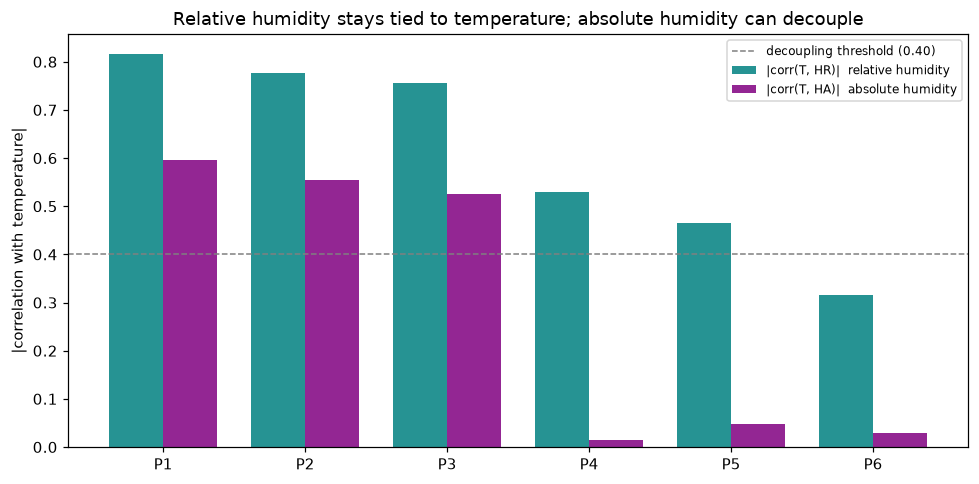

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
periods = sorted(d["period"].unique()); x = np.arange(len(periods)); w = 0.38
chr_ = [abs(d[d.period==p]["T"].corr(d[d.period==p]["HR"])) for p in periods]
cha  = [abs(d[d.period==p]["T"].corr(d[d.period==p]["HA"])) for p in periods]
ax.bar(x-w/2, chr_, w, label="|corr(T, HR)|  relative humidity", color="teal", alpha=0.85)
ax.bar(x+w/2, cha,  w, label="|corr(T, HA)|  absolute humidity", color="purple", alpha=0.85)
ax.axhline(0.40, ls="--", c="grey", lw=1, label="decoupling threshold (0.40)")
ax.set_xticks(x); ax.set_xticklabels(periods); ax.set_ylabel("|correlation with temperature|")
ax.set_title("Relative humidity stays tied to temperature; absolute humidity can decouple")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Relative humidity (teal) is coupled to temperature in every period — often strongly —
because RH is defined against a temperature-dependent saturation point, so it partly
restates temperature. Absolute humidity (purple) drops below the decoupling threshold in
several periods. This is the crux Part 2 exploits: to estimate a humidity effect *cleanly*,
one must work in periods where humidity and temperature are not collinear — and those
periods exist mainly for **absolute** humidity, not relative.

### 4.3 Physical consistency of the humidity chain

Absolute humidity (g/m^3):
min      1.79
mean     8.99
max     15.95
Name: abs_humidity_gm3, dtype: float64


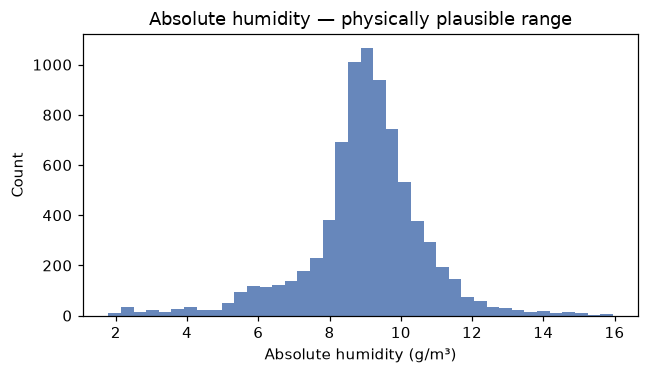

In [8]:
print("Absolute humidity (g/m^3):")
print(df["abs_humidity_gm3"].describe()[["min","mean","max"]].round(2))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df["abs_humidity_gm3"], bins=40, color="#4c72b0", alpha=0.85)
ax.set_xlabel("Absolute humidity (g/m³)"); ax.set_ylabel("Count")
ax.set_title("Absolute humidity — physically plausible range")
plt.tight_layout(); plt.show()

Values sit in the ~5–20 g/m³ range typical of indoor/industrial air — the Magnus chain is internally consistent.

## 5. Output

`synthetic_global.csv` — ~7,900 rows over six operating periods — carries a **dominant
temperature effect** on cooling time, a **small secondary humidity effect**, and a
**temperature/humidity collinearity that is milder for absolute humidity than relative**.

**Part 2** detects the periods, classifies each by the study's four scenarios (temperature
strong / temperature weak / relative-humidity-decoupled / absolute-humidity-decoupled),
fits the regression family in each, and reaches the study's conclusion about whether a
humidity effect can be established at all with this instrumentation.